In [26]:
import pandas as pd
import numpy as np 

In [27]:
# Loading confirmed Hsp90β clients - POSITIVES
df_pos = pd.read_excel("human_mouse_mito_overlay.xlsx",
                        sheet_name="Hsp90-dependent subset")

# Loading full proteomics - for NEGATIVES
df_full = pd.read_excel("human_mouse_mito_overlay.xlsx",
                         sheet_name="treatment_groups_proteomics")

# Filtering negatives
df_neg = df_full[
    (df_full['Increase with Val'].abs() < 0.3) &
    (df_full['Decrease with Gel'].abs() < 0.3)
].copy()

print("Positives:", len(df_pos))
print("Negatives:", len(df_neg))


Positives: 46
Negatives: 4045


In [28]:
# Keeping only common columns
common_cols = ['Gene names', 'Increase with Val', 'Decrease with Gel']
df_pos_clean = df_pos[common_cols].copy()
df_neg_clean = df_neg[common_cols].copy()

# Adding labels
df_pos_clean['label'] = 1
df_neg_clean['label'] = 0

# Combining
df_combined = pd.concat([df_pos_clean, df_neg_clean],
                         ignore_index=True)

print("Total:", len(df_combined))
print("Positives:", (df_combined['label'] == 1).sum())
print("Negatives:", (df_combined['label'] == 0).sum())

Total: 4091
Positives: 46
Negatives: 4045


In [29]:
# Loading Beta KO RNA data
df_beta = pd.read_excel(
    "Copy of betaKO_rna_protein_mapped_aug182024.xlsx",
    sheet_name="rna_WT_vs_Beta"
)

# Keeping only columns we need
df_beta_clean = df_beta[['Gene Symbol', 'logFC',
                          'PValue (FDR)', 'logCPM']].copy()
df_beta_clean.columns = ['Gene names', 'betaKO_logFC',
                          'betaKO_FDR', 'betaKO_logCPM']

print("Beta KO shape:", df_beta_clean.shape)

Beta KO shape: (14943, 4)


In [30]:
# Coverting into lowercase for matching
df_combined['gene_lower'] = df_combined['Gene names'].str.lower()
df_beta_clean['gene_lower'] = df_beta_clean['Gene names'].str.lower()

# Merging
df_combined2 = df_combined.merge(
    df_beta_clean[['gene_lower', 'betaKO_logFC',
                   'betaKO_FDR', 'betaKO_logCPM']],
    on='gene_lower',
    how='left'
)

# Removing duplicates
df_combined2 = df_combined2.drop_duplicates(
    subset=['Gene names', 'label']
).reset_index(drop=True)

# Filling the unmatched with neutral values
df_combined2['betaKO_logFC'] = df_combined2['betaKO_logFC'].fillna(0)
df_combined2['betaKO_FDR'] = df_combined2['betaKO_FDR'].fillna(1)
df_combined2['betaKO_logCPM'] = df_combined2['betaKO_logCPM'].fillna(0)

# Dropping helper column
df_combined2 = df_combined2.drop(columns=['gene_lower'])

print("Shape:", df_combined2.shape)
print("Positives:", (df_combined2['label'] == 1).sum())
print("Negatives:", (df_combined2['label'] == 0).sum())
print("\nColumns:", df_combined2.columns.tolist())
df_combined2.head()

Shape: (4084, 7)
Positives: 46
Negatives: 4038

Columns: ['Gene names', 'Increase with Val', 'Decrease with Gel', 'label', 'betaKO_logFC', 'betaKO_FDR', 'betaKO_logCPM']


,Gene names,Increase with Val,Decrease with Gel,label,betaKO_logFC,betaKO_FDR,betaKO_logCPM
0,OTC,3.058773,-1.330122,1,0.0000,1.0000,0.0000
1,NDUFA2,1.597137,-0.913500,1,-0.0868,1.0000,4.4330
2,PMPCB,2.242986,-0.696656,1,0.1314,1.0000,6.8013
3,AIFM1,2.874427,-1.386690,1,0.2869,0.9236,4.5038
4,GLUD1;GLUD2,2.057409,-0.739972,1,0.0000,1.0000,0.0000


In [31]:
# Loading Alpha vs Beta comparison
df_alpha = pd.read_excel("Diff_Exp_Combined_Outliers_removed.xlsx",
                          sheet_name="Alpha_vs_Beta")

# Keeping only columns we need
df_alpha_clean = df_alpha[['Gene Symbol', 'logFC',
                            'PValue (FDR)']].copy()
df_alpha_clean.columns = ['Gene names', 'alphaVSbeta_logFC',
                           'alphaVSbeta_FDR']

# Lowercase for matching
df_alpha_clean['gene_lower'] = df_alpha_clean['Gene names'].str.lower()
df_combined2['gene_lower'] = df_combined2['Gene names'].str.lower()

# Merging
df_combined3 = df_combined2.merge(
    df_alpha_clean[['gene_lower', 'alphaVSbeta_logFC',
                    'alphaVSbeta_FDR']],
    on='gene_lower',
    how='left'
)

# Removing duplicates
df_combined3 = df_combined3.drop_duplicates(
    subset=['Gene names', 'label']
).reset_index(drop=True)

# Filling unmatched with neutral values
df_combined3['alphaVSbeta_logFC'] = df_combined3['alphaVSbeta_logFC'].fillna(0)
df_combined3['alphaVSbeta_FDR'] = df_combined3['alphaVSbeta_FDR'].fillna(1)

# Dropping helper column
df_combined3 = df_combined3.drop(columns=['gene_lower'])

print("Final shape:", df_combined3.shape)
print("Positives:", (df_combined3['label'] == 1).sum())
print("Negatives:", (df_combined3['label'] == 0).sum())
print("\nFinal columns:", df_combined3.columns.tolist())
df_combined3.head()


Final shape: (4084, 9)
Positives: 46
Negatives: 4038

Final columns: ['Gene names', 'Increase with Val', 'Decrease with Gel', 'label', 'betaKO_logFC', 'betaKO_FDR', 'betaKO_logCPM', 'alphaVSbeta_logFC', 'alphaVSbeta_FDR']


,Gene names,Increase with Val,Decrease with Gel,label,betaKO_logFC,betaKO_FDR,betaKO_logCPM,alphaVSbeta_logFC,alphaVSbeta_FDR
0,OTC,3.058773,-1.330122,1,0.0000,1.0000,0.0000,0.0000,1.0
1,NDUFA2,1.597137,-0.913500,1,-0.0868,1.0000,4.4330,-0.1258,1.0
2,PMPCB,2.242986,-0.696656,1,0.1314,1.0000,6.8013,-0.0157,1.0
3,AIFM1,2.874427,-1.386690,1,0.2869,0.9236,4.5038,0.0683,1.0
4,GLUD1;GLUD2,2.057409,-0.739972,1,0.0000,1.0000,0.0000,0.0000,1.0


In [32]:
#Loading the differential expression datasets
xl3 = pd.ExcelFile("Diff_Exp_Combined_Outliers_removed.xlsx")
print("Sheets:", xl3.sheet_names)

df_alpha = pd.read_excel("Diff_Exp_Combined_Outliers_removed.xlsx", 
                         sheet_name = "Alpha_vs_Beta")
print("Shape:", df_alpha.shape)
print("\n Columns:", df_alpha.columns.tolist())
print("\nFirst 3 rows:")
df_alpha.head(3)

Sheets: ['WT_vs_Alpha', 'WT_vs_Beta', 'Alpha_vs_Beta']
Shape: (14921, 26)

 Columns: ['gene_id', 'FC', 'logFC', 'logCPM', 'PValue (raw)', 'PValue (FDR)', 'refseq_mrna', 'refseq_ncrna', 'Gene Symbol', 'description', 'X752_ALPHA.cpm', 'X978_ALPHA.cpm', 'X986_ALPHA.cpm', 'X989_ALPHA.cpm', 'X164_BETA.cpm', 'X969_BETA.cpm', 'X973_BETA.cpm', 'X974_BETA.cpm', 'X752_ALPHA.counts', 'X978_ALPHA.counts', 'X986_ALPHA.counts', 'X989_ALPHA.counts', 'X164_BETA.counts', 'X969_BETA.counts', 'X973_BETA.counts', 'X974_BETA.counts']

First 3 rows:


,gene_id,FC,logFC,logCPM,PValue (raw),PValue (FDR),refseq_mrna,refseq_ncrna,Gene Symbol,description,...,X973_BETA.cpm,X974_BETA.cpm,X752_ALPHA.counts,X978_ALPHA.counts,X986_ALPHA.counts,X989_ALPHA.counts,X164_BETA.counts,X969_BETA.counts,X973_BETA.counts,X974_BETA.counts
0,ENSMUSG00000059824,3.0435,1.6057,4.8834,0.0,0.0,NM_016974,NaN,Dbp,D site albumin promoter binding protein [Sourc...,...,46.8573,34.7018,187.000,208.000,334.999,251.000,670.001,1016.00,803.000,600.000
1,ENSMUSG00000021270,-2.1789,-1.1236,7.2513,0.0,0.0,NM_010480,NaN,Hsp90aa1,"heat shock protein 90, alpha (cytosolic), clas...",...,94.5844,82.1823,2232.909,3615.366,4490.120,3805.318,2067.052,1728.83,1620.907,1420.946
2,ENSMUSG00000119895,4.8257,2.2707,1.0066,0.0,0.0,NaN,NaN,Gm22513,"predicted gene, 22513 [Source:MGI Symbol;Acc:M...",...,3.3261,2.7183,13.000,10.000,15.000,4.000,60.000,57.00,57.000,47.000


In [33]:
# Keeping only columns we need from Alpha vs Beta
df_alpha_clean = df_alpha[['Gene Symbol', 'logFC', 
                            'PValue (FDR)']].copy()

# Renaming clearly
df_alpha_clean.columns = ['Gene names', 'alphaVSbeta_logFC', 
                           'alphaVSbeta_FDR']

# Lowercase for matching
df_alpha_clean['gene_lower'] = df_alpha_clean['Gene names'].str.lower()
df_combined2['gene_lower'] = df_combined2['Gene names'].str.lower()

# Merging
df_combined3 = df_combined2.merge(
    df_alpha_clean[['gene_lower', 'alphaVSbeta_logFC', 
                    'alphaVSbeta_FDR']],
    on='gene_lower',
    how='left'
)

# Removing duplicates
df_combined3 = df_combined3.drop_duplicates(
    subset=['Gene names', 'label']
).reset_index(drop=True)

# Filling unmatched with neutral values
df_combined3['alphaVSbeta_logFC'] = df_combined3['alphaVSbeta_logFC'].fillna(0)
df_combined3['alphaVSbeta_FDR'] = df_combined3['alphaVSbeta_FDR'].fillna(1)

# Dropping helper column
df_combined3 = df_combined3.drop(columns=['gene_lower'])

print("Final shape:", df_combined3.shape)
print("Positives:", (df_combined3['label'] == 1).sum())
print("Negatives:", (df_combined3['label'] == 0).sum())
print("\nFinal columns:", df_combined3.columns.tolist())
print("\nFirst 5 rows:")
df_combined3.head()

Final shape: (4084, 9)
Positives: 46
Negatives: 4038

Final columns: ['Gene names', 'Increase with Val', 'Decrease with Gel', 'label', 'betaKO_logFC', 'betaKO_FDR', 'betaKO_logCPM', 'alphaVSbeta_logFC', 'alphaVSbeta_FDR']

First 5 rows:


,Gene names,Increase with Val,Decrease with Gel,label,betaKO_logFC,betaKO_FDR,betaKO_logCPM,alphaVSbeta_logFC,alphaVSbeta_FDR
0,OTC,3.058773,-1.330122,1,0.0000,1.0000,0.0000,0.0000,1.0
1,NDUFA2,1.597137,-0.913500,1,-0.0868,1.0000,4.4330,-0.1258,1.0
2,PMPCB,2.242986,-0.696656,1,0.1314,1.0000,6.8013,-0.0157,1.0
3,AIFM1,2.874427,-1.386690,1,0.2869,0.9236,4.5038,0.0683,1.0
4,GLUD1;GLUD2,2.057409,-0.739972,1,0.0000,1.0000,0.0000,0.0000,1.0


In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (StratifiedKFold, GridSearchCV,
                                      cross_val_predict, 
                                      permutation_test_score)
from sklearn.metrics import (roc_auc_score, f1_score,
                              matthews_corrcoef, roc_curve,
                              auc, average_precision_score)
import matplotlib.pyplot as plt
import numpy as np

In [35]:

# FINAL FEATURE SET - RECOMMENDED
# Include pharmacological response but remove molecular               weight
# Mol weight caused perfect AUC due to size bias


feature_columns = [
    'betaKO_logFC',       # RNA change in Beta KO
    'betaKO_FDR',         # confidence of Beta KO change
    'betaKO_logCPM',      # expression level in cardiac tissue
    'alphaVSbeta_logFC',  # isoform specificity
    'alphaVSbeta_FDR'     # confidence of isoform difference
]

X = df_combined3[feature_columns].values
y = df_combined3['label'].values

print("Feature matrix shape:", X.shape)
print("Features:", feature_columns)

Feature matrix shape: (4084, 5)
Features: ['betaKO_logFC', 'betaKO_FDR', 'betaKO_logCPM', 'alphaVSbeta_logFC', 'alphaVSbeta_FDR']


In [36]:

# RANDOM FOREST - NESTED CROSS VALIDATION
# Final feature set - pharmacological + transcriptomic
# Molecular weight removed to avoid size bias
# As recommended by professor


outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

param_grid = {
    'n_estimators'     : [100, 300],
    'max_depth'        : [3, 5, None],
    'min_samples_leaf' : [1, 5, 10]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    param_grid=param_grid,
    scoring='roc_auc',
    cv=inner_cv,
    n_jobs=-1
)

# Storage for results and ROC curve
outer_auc_scores = []
outer_ap_scores  = []
all_y_true       = []
all_y_prob       = []
fold_number      = 1

print("Running Nested Cross Validation...")
print("Features: pharmacological + transcriptomic")
print("=" * 55)

for train_idx, test_idx in outer_cv.split(X, y):
    X_train = X[train_idx]
    X_test  = X[test_idx]
    y_train = y[train_idx]
    y_test  = y[test_idx]

    # Inner loop tunes hyperparameters
    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_

    # Evaluate on outer test fold
    y_prob = best_model.predict_proba(X_test)[:, 1]

    fold_auc = roc_auc_score(y_test, y_prob)
    fold_ap  = average_precision_score(y_test, y_prob)

    outer_auc_scores.append(fold_auc)
    outer_ap_scores.append(fold_ap)
    all_y_true.extend(y_test)
    all_y_prob.extend(y_prob)

    print(f"  Fold {fold_number}: AUC={fold_auc:.4f}  "
          f"AP={fold_ap:.4f}  "
          f"Best={grid_search.best_params_}")
    fold_number += 1

print("=" * 55)
print(f"\nFINAL RESULTS (Unbiased Nested CV):")
print(f"  ROC-AUC          : {np.mean(outer_auc_scores):.4f} "
      f"+/- {np.std(outer_auc_scores):.4f}")
print(f"  Avg Precision    : {np.mean(outer_ap_scores):.4f} "
      f"+/- {np.std(outer_ap_scores):.4f}")

Running Nested Cross Validation...
Features: pharmacological + transcriptomic
  Fold 1: AUC=0.7560  AP=0.0260  Best={'max_depth': None, 'min_samples_leaf': 10, 'n_estimators': 100}
  Fold 2: AUC=0.7022  AP=0.1341  Best={'max_depth': None, 'min_samples_leaf': 10, 'n_estimators': 300}
  Fold 3: AUC=0.6885  AP=0.0213  Best={'max_depth': None, 'min_samples_leaf': 10, 'n_estimators': 300}
  Fold 4: AUC=0.5829  AP=0.0173  Best={'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 300}
  Fold 5: AUC=0.5927  AP=0.0161  Best={'max_depth': 3, 'min_samples_leaf': 5, 'n_estimators': 100}

FINAL RESULTS (Unbiased Nested CV):
  ROC-AUC          : 0.6644 +/- 0.0666
  Avg Precision    : 0.0430 +/- 0.0457


Feature Importances:
  betaKO_FDR               : 0.0558
  alphaVSbeta_FDR          : 0.0964
  betaKO_logCPM            : 0.2548
  betaKO_logFC             : 0.2714
  alphaVSbeta_logFC        : 0.3217


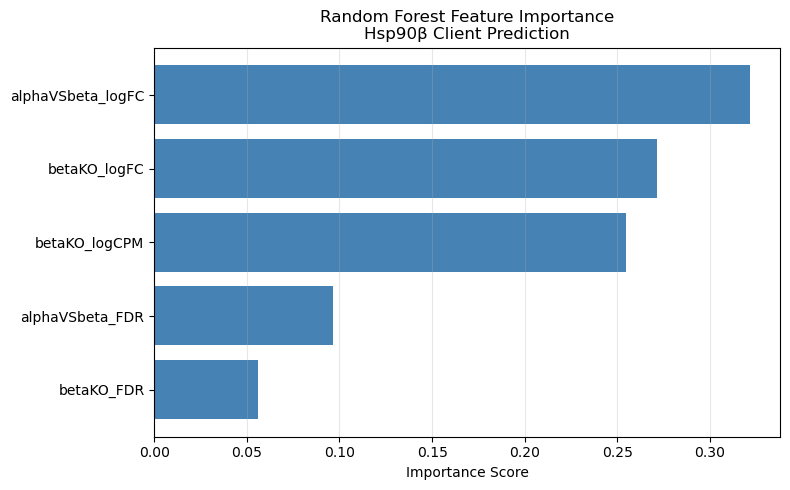


Saved as feature_importance_rf.png


In [37]:

# FEATURE IMPORTANCE - RANDOM FOREST
# Train on full dataset to get importance scores


best_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

best_rf.fit(X, y)

importance_df = pd.DataFrame({
    'Feature'    : feature_columns,
    'Importance' : best_rf.feature_importances_
}).sort_values('Importance', ascending=True)

# Print values
print("Feature Importances:")
print("=" * 45)
for _, row in importance_df.iterrows():
    print(f"  {row['Feature']:25s}: {row['Importance']:.4f}")

# Simple bar plot
fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(importance_df['Feature'],
        importance_df['Importance'],
        color='steelblue')

ax.set_xlabel('Importance Score')
ax.set_title('Random Forest Feature Importance\n'
             'Hsp90\u03b2 Client Prediction')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('feature_importance_rf.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved as feature_importance_rf.png")

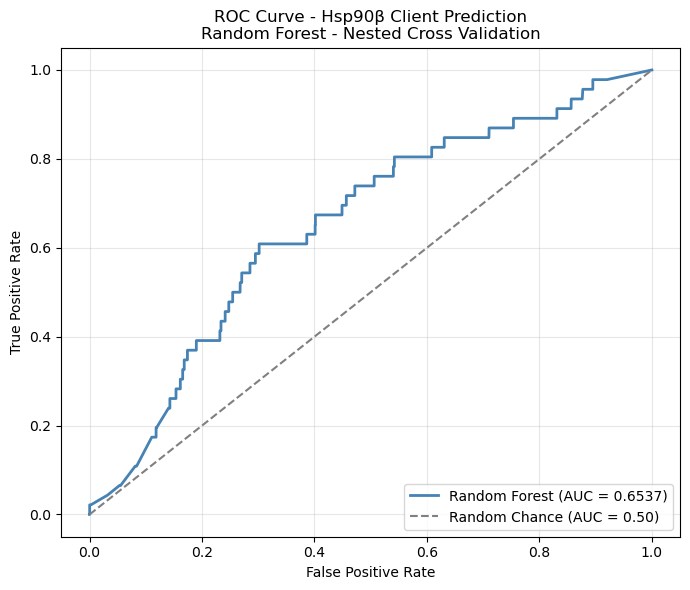

In [38]:

# ROC CURVE - RANDOM FOREST FINAL


fpr, tpr, _ = roc_curve(all_y_true, all_y_prob)
roc_auc_final = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(fpr, tpr, color='steelblue', linewidth=2,
        label=f'Random Forest (AUC = {roc_auc_final:.4f})')

ax.plot([0, 1], [0, 1], color='gray', linestyle='--',
        label='Random Chance (AUC = 0.50)')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve - Hsp90\u03b2 Client Prediction\n'
             'Random Forest - Nested Cross Validation')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curve_rf_final.png',
            dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()


Running SVM Nested Cross Validation...
  Fold 1: AUC=0.9001  AP=0.1624  Best={'C': 100, 'gamma': 0.01}
  Fold 2: AUC=0.7154  AP=0.0405  Best={'C': 10, 'gamma': 'scale'}
  Fold 3: AUC=0.7812  AP=0.0542  Best={'C': 100, 'gamma': 'scale'}
  Fold 4: AUC=0.6759  AP=0.0467  Best={'C': 100, 'gamma': 'scale'}
  Fold 5: AUC=0.6273  AP=0.0173  Best={'C': 10, 'gamma': 'scale'}

SVM FINAL RESULTS (Unbiased Nested CV):
  ROC-AUC   : 0.7400+/- 0.0946
  Avg Precision : 0.0642+/- 0.0506


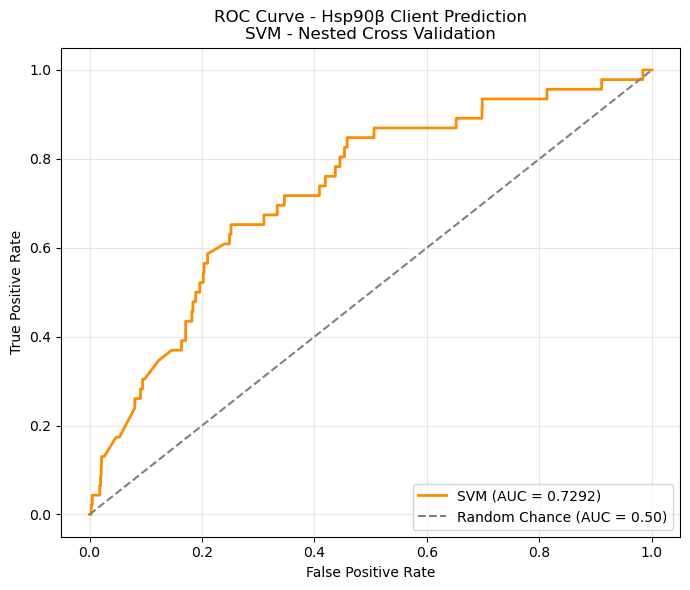

SVM AUC: 0.7292


In [39]:
##SVM model - Nested cross validation 
##Using same 5 features and using same 5 nested CV as Random Forest
##RBF kernel handles 
#Class_weight = balanced for 1 positives for every 86 negetives

from sklearn.svm import SVC

svm_param_grid = {
    'C'      :[0.1,1,10,100],      #regularization strength
    'gamma'  :['scale', 0.01,0.001]  #kernel width
}
 
svm_grid_search = GridSearchCV(
    estimator = SVC(
        kernel = 'rbf',
        class_weight = 'balanced',
        probability = True,
        random_state = 42
    ),
    param_grid = svm_param_grid,
    scoring = 'roc_auc',
    cv = inner_cv,
    n_jobs = 1
)

##Storing results
svm_auc_scores = []
svm_ap_scores = []
svm_y_true = []
svm_y_prob = []
fold_number = 1
print("Running SVM Nested Cross Validation...")
print("=" * 55)

for train_idx, test_idx in outer_cv.split(X, y):
    X_train = X[train_idx]
    X_test = X[test_idx]
    y_train = y[train_idx]
    y_test = y[test_idx]

 
    # Inner loop tunes C and gamma
    svm_grid_search.fit(X_train, y_train)
    best_svm = svm_grid_search.best_estimator_

    # Evaluate on outer test fold
    y_prob = best_svm.predict_proba(X_test)[:, 1]

    fold_auc = roc_auc_score(y_test, y_prob)
    fold_ap  = average_precision_score(y_test, y_prob)

    svm_auc_scores.append(fold_auc)
    svm_ap_scores.append(fold_ap)
    svm_y_true.extend(y_test)
    svm_y_prob.extend(y_prob)

    print(f"  Fold {fold_number}: AUC={fold_auc:.4f}  "
          f"AP={fold_ap:.4f}  "
          f"Best={svm_grid_search.best_params_}")
    fold_number += 1 

print("=" * 55)
print(f"\nSVM FINAL RESULTS (Unbiased Nested CV):")
print(f"  ROC-AUC   : {np.mean(svm_auc_scores):.4f}"
      f"+/- {np.std(svm_auc_scores):.4f}")
print(f"  Avg Precision : {np.mean(svm_ap_scores):.4f}"
      f"+/- {np.std(svm_ap_scores):.4f}")


###ROC curve for SVM

fpr_svm, tpr_svm, _ = roc_curve(svm_y_true, svm_y_prob)
roc_auc_svm = auc(fpr_svm, tpr_svm)

fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(fpr_svm, tpr_svm, color='darkorange', linewidth=2,
        label=f'SVM (AUC = {roc_auc_svm:.4f})')

ax.plot([0, 1], [0, 1], color='gray', linestyle='--',
        label='Random Chance (AUC = 0.50)')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve - Hsp90\u03b2 Client Prediction\n'
             'SVM - Nested Cross Validation')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curve_svm.png',
            dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print(f"SVM AUC: {roc_auc_svm:.4f}")

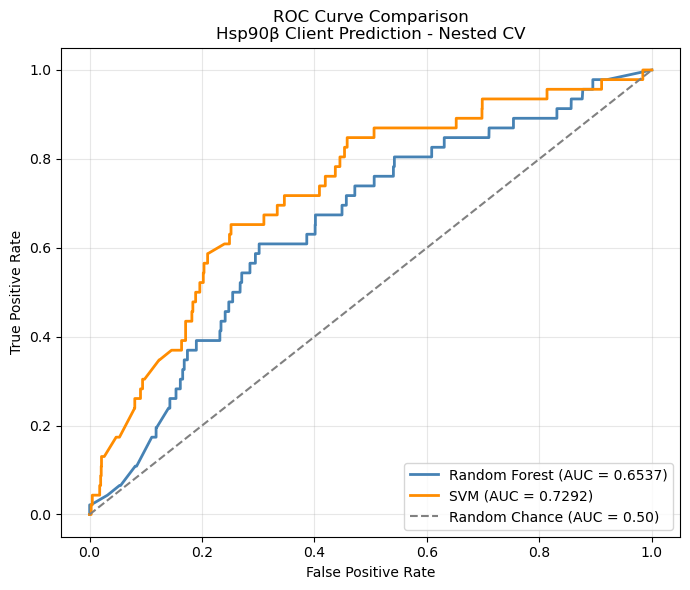

Saved as roc_curve_combined.png


In [40]:
###Combined ROC Curve   RF and SVM together

fpr_rf, tpr_rf, _ = roc_curve(all_y_true, all_y_prob)
roc_auc_rf = auc(fpr_rf, tpr_rf)

fig, ax = plt.subplots(figsize=(7,6))

#Random Forest 
ax.plot(fpr_rf, tpr_rf, color='steelblue', linewidth=2,
        label=f'Random Forest (AUC = {roc_auc_rf:.4f})')

# SVM
ax.plot(fpr_svm, tpr_svm, color='darkorange', linewidth=2,
        label=f'SVM (AUC = {roc_auc_svm:.4f})')

# Random chance
ax.plot([0, 1], [0, 1], color='gray', linestyle='--',
        label='Random Chance (AUC = 0.50)')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison\n'
             'Hsp90\u03b2 Client Prediction - Nested CV')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curve_combined.png',
            dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print("Saved as roc_curve_combined.png")


In [41]:

# NEURAL NETWORK - MLP CLASSIFIER


from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score
import numpy as np

# Define CV first before using them
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Pipeline - scaling + neural network together
nn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(
        random_state=42,
        max_iter=1000,
        early_stopping=True,
        validation_fraction=0.1
    ))
])

# Hyperparameter grid
nn_param_grid = {
    'mlp__hidden_layer_sizes' : [(64,), (32, 16), (64, 32)],
    'mlp__alpha'              : [0.001, 0.01, 0.1],
    'mlp__learning_rate_init' : [0.001, 0.01]
}

nn_grid_search = GridSearchCV(
    estimator=nn_pipeline,
    param_grid=nn_param_grid,
    scoring='roc_auc',
    cv=inner_cv,
    n_jobs=-1
)

# Storage
nn_auc_scores = []
nn_ap_scores  = []
nn_y_true     = []
nn_y_prob     = []
fold_number   = 1

print("Running Neural Network Nested Cross Validation...")
print("=" * 55)

for train_idx, test_idx in outer_cv.split(X, y):
    X_train = X[train_idx]
    X_test  = X[test_idx]
    y_train = y[train_idx]
    y_test  = y[test_idx]

    nn_grid_search.fit(X_train, y_train)
    best_nn = nn_grid_search.best_estimator_

    y_prob = best_nn.predict_proba(X_test)[:, 1]

    fold_auc = roc_auc_score(y_test, y_prob)
    fold_ap  = average_precision_score(y_test, y_prob)

    nn_auc_scores.append(fold_auc)
    nn_ap_scores.append(fold_ap)
    nn_y_true.extend(y_test)
    nn_y_prob.extend(y_prob)

    print(f"  Fold {fold_number}: AUC={fold_auc:.4f}  "
          f"AP={fold_ap:.4f}  "
          f"Best={nn_grid_search.best_params_}")
    fold_number += 1

print("=" * 55)
print(f"\nNEURAL NETWORK FINAL RESULTS:")
print(f"  ROC-AUC       : {np.mean(nn_auc_scores):.4f} "
      f"+/- {np.std(nn_auc_scores):.4f}")
print(f"  Avg Precision : {np.mean(nn_ap_scores):.4f} "
      f"+/- {np.std(nn_ap_scores):.4f}")

Running Neural Network Nested Cross Validation...
  Fold 1: AUC=0.6278  AP=0.0194  Best={'mlp__alpha': 0.001, 'mlp__hidden_layer_sizes': (64,), 'mlp__learning_rate_init': 0.001}
  Fold 2: AUC=0.3272  AP=0.0086  Best={'mlp__alpha': 0.01, 'mlp__hidden_layer_sizes': (64,), 'mlp__learning_rate_init': 0.01}
  Fold 3: AUC=0.5003  AP=0.0114  Best={'mlp__alpha': 0.001, 'mlp__hidden_layer_sizes': (64,), 'mlp__learning_rate_init': 0.001}
  Fold 4: AUC=0.4829  AP=0.0124  Best={'mlp__alpha': 0.001, 'mlp__hidden_layer_sizes': (64,), 'mlp__learning_rate_init': 0.001}
  Fold 5: AUC=0.3410  AP=0.0087  Best={'mlp__alpha': 0.001, 'mlp__hidden_layer_sizes': (64,), 'mlp__learning_rate_init': 0.001}

NEURAL NETWORK FINAL RESULTS:
  ROC-AUC       : 0.4558 +/- 0.1113
  Avg Precision : 0.0121 +/- 0.0039


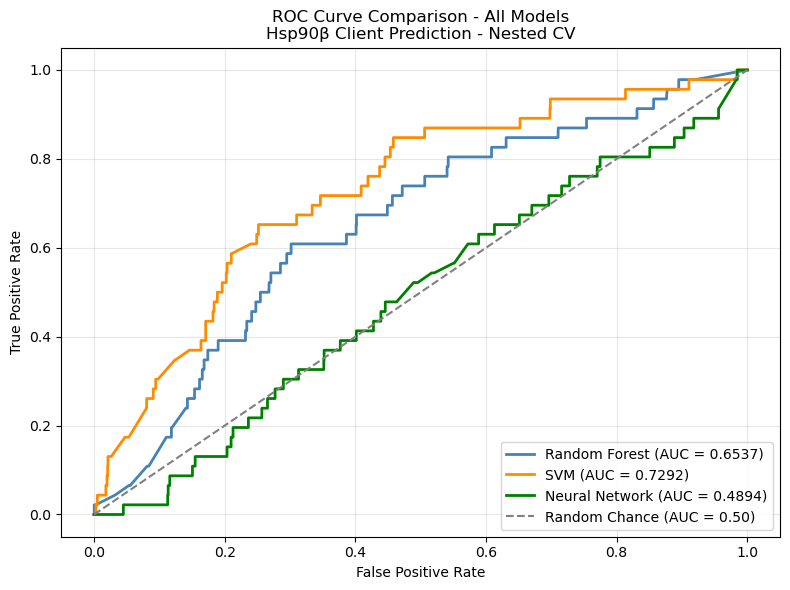

Saved as roc_curve_all_models.png


In [42]:

# FINAL COMBINED ROC CURVE - ALL THREE MODELS


from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calculate ROC curves
fpr_rf, tpr_rf, _ = roc_curve(all_y_true, all_y_prob)
fpr_svm, tpr_svm, _ = roc_curve(svm_y_true, svm_y_prob)
fpr_nn, tpr_nn, _ = roc_curve(nn_y_true, nn_y_prob)

roc_auc_rf  = auc(fpr_rf, tpr_rf)
roc_auc_svm = auc(fpr_svm, tpr_svm)
roc_auc_nn  = auc(fpr_nn, tpr_nn)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(fpr_rf, tpr_rf, color='steelblue', linewidth=2,
        label=f'Random Forest (AUC = {roc_auc_rf:.4f})')

ax.plot(fpr_svm, tpr_svm, color='darkorange', linewidth=2,
        label=f'SVM (AUC = {roc_auc_svm:.4f})')

ax.plot(fpr_nn, tpr_nn, color='green', linewidth=2,
        label=f'Neural Network (AUC = {roc_auc_nn:.4f})')

ax.plot([0, 1], [0, 1], color='gray', linestyle='--',
        label='Random Chance (AUC = 0.50)')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison - All Models\n'
             'Hsp90\u03b2 Client Prediction - Nested CV')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curve_all_models.png',
            dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print("Saved as roc_curve_all_models.png")

In [43]:

# HAX-1 AND CypD PREDICTION USING BEST MODEL (SVM)
# We already found their feature values earlier:
# HAX-1 (Hax1) and CypD (Ppif) exist in our datasets
# We construct their feature vectors and predict

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
import numpy as np

# Train final SVM on ALL training data with best params
# Best params found during nested CV: C=100, gamma='scale'
final_svm = SVC(
    kernel='rbf',
    C=100,
    gamma='scale',
    class_weight='balanced',
    probability=True,
    random_state=42
)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train on full dataset
final_svm.fit(X_scaled, y)
print("SVM trained on full dataset")

# HAX-1 feature vector
# betaKO_logFC, betaKO_FDR, betaKO_logCPM,
# alphaVSbeta_logFC, alphaVSbeta_FDR


hax1_features = np.array([[
    -0.2034,   # betaKO_logFC
     1.0000,   # betaKO_FDR
     3.8846,   # betaKO_logCPM
    -0.1595,   # alphaVSbeta_logFC
     0.9636    # alphaVSbeta_FDR
]])

# CypD (PPIF) feature vector
cypd_features = np.array([[
    -0.0167,   # betaKO_logFC
     1.0000,   # betaKO_FDR
     6.7895,   # betaKO_logCPM
    -0.2654,   # alphaVSbeta_logFC
     0.8722    # alphaVSbeta_FDR
]])

# Scale using same scaler fitted on training data
hax1_scaled = scaler.transform(hax1_features)
cypd_scaled  = scaler.transform(cypd_features)

# Get predictions
hax1_prob = final_svm.predict_proba(hax1_scaled)[0, 1]
cypd_prob  = final_svm.predict_proba(cypd_scaled)[0, 1]

hax1_pred = final_svm.predict(hax1_scaled)[0]
cypd_pred  = final_svm.predict(cypd_scaled)[0]

###Displaying results

print("\n" + "=" * 55)
print("Hsp90β CLIENT PREDICTION RESULTS")
print("=" * 55)

for name, prob, pred in [
    ("HAX-1 (Hax1)", hax1_prob, hax1_pred),
    ("CypD  (Ppif)", cypd_prob, cypd_pred)
]:
    label = "CLIENT" if pred == 1 else "NON-CLIENT"

    if prob >= 0.6:
        confidence = "HIGH confidence Hsp90β client"
    elif prob >= 0.4:
        confidence = "MODERATE - possible client"
    else:
        confidence = "LOW - unlikely canonical client"

    print(f"\nProtein  : {name}")
    print(f"  Probability : {prob:.4f} ({prob*100:.1f}%)")
    print(f"  Prediction  : {label}")
    print(f"  Confidence  : {confidence}")

print("\n" + "=" * 55)
print("NOTE: Low scores suggest post-translational")
print("regulation rather than transcriptional response")
print("consistent with known Hsp90β-HAX1-CypD biology")


SVM trained on full dataset

Hsp90β CLIENT PREDICTION RESULTS

Protein  : HAX-1 (Hax1)
  Probability : 0.0131 (1.3%)
  Prediction  : CLIENT
  Confidence  : LOW - unlikely canonical client

Protein  : CypD  (Ppif)
  Probability : 0.0141 (1.4%)
  Prediction  : CLIENT
  Confidence  : LOW - unlikely canonical client

NOTE: Low scores suggest post-translational
regulation rather than transcriptional response
consistent with known Hsp90β-HAX1-CypD biology


In [44]:

# DISEASE VALIDATION
# Checking if high confidence Hsp90β predictions overlap
# with proteins dysregulated in human heart failure
# File 1: LamCK human cardiac ICM vs Non-Failing


# Loading File 1 - human cardiac data
df_cardiac = pd.read_excel(
    "LamCK_062223_cyclicloess_Ttest (2).xlsx",
    sheet_name="cyclic_loess_data",
    header=None
)

print("Cardiac data shape:", df_cardiac.shape)
print("\nFirst 5 rows first 10 cols:")
print(df_cardiac.iloc[:5, :10].to_string())

Cardiac data shape: (99, 39)

First 5 rows first 10 cols:
            0                                                                                                 1            2            3            4            5            6            7            8            9
0         NaN                                                                                               NaN          NaN          NaN          NaN          NaN          NaN          NaN          NaN          NaN
1         NaN                                                                                               NaN  Non_Failing  Non_Failing  Non_Failing  Non_Failing  Non_Failing  Non_Failing  Failing_ICM  Failing_ICM
2  uniprot_id                                                                                      Protein Name        A0470        A0535        A0597        A0598        A0662        A0727        A0310        A0319
3      P12883                           sp|P12883|MYH7_HUMAN Myosin-7 OS=Homo 

In [45]:

# DISEASE VALIDATION - EXTRACT AND ANALYZE


# Row 1 has condition labels (Non_Failing vs Failing_ICM)
# Row 2 has sample IDs
# Row 3 onwards has protein data
# Col 0 = uniprot_id, Col 1 = Protein Name

# Extracting condition labels from row 1
conditions = df_cardiac.iloc[1, :].tolist()

# Finding which columns are Non_Failing and Failing_ICM
nf_cols  = [i for i, c in enumerate(conditions) 
             if str(c) == 'Non_Failing']
icm_cols = [i for i, c in enumerate(conditions) 
             if str(c) == 'Failing_ICM']

print("Non_Failing columns:", nf_cols)
print("Failing_ICM columns:", icm_cols)

# Extracting protein data starting from row 3
df_cardiac_clean = df_cardiac.iloc[3:, :].copy()
df_cardiac_clean.columns = df_cardiac.iloc[2, :].tolist()
df_cardiac_clean = df_cardiac_clean.reset_index(drop=True)

print("\nCleaned cardiac data shape:", df_cardiac_clean.shape)
print("Columns:", df_cardiac_clean.columns[:5].tolist())
print("\nFirst 3 rows:")
df_cardiac_clean.iloc[:3, :4]

Non_Failing columns: [2, 3, 4, 5, 6, 7]
Failing_ICM columns: [8, 9, 10, 11, 12, 13]

Cleaned cardiac data shape: (96, 39)
Columns: ['uniprot_id', 'Protein Name', 'A0470', 'A0535', 'A0597']

First 3 rows:


,uniprot_id,Protein Name,A0470,A0535
0,P12883,sp|P12883|MYH7_HUMAN Myosin-7 OS=Homo sapiens ...,24.205932,25.051009
1,P13645,"sp|P13645|K1C10_HUMAN Keratin, type I cytoskel...",27.798817,27.002815
2,P08238,sp|P08238|HS90B_HUMAN Heat shock protein HSP 9...,26.476429,28.423455


In [46]:

# CALCULATE DYSREGULATION IN HUMAN HEART FAILURE
# Compare Non-Failing vs Failing ICM protein abundance


from scipy import stats
import numpy as np

# Get sample column names
sample_cols = df_cardiac.iloc[2, :].tolist()

# Non-Failing sample names (columns 2-7)
nf_sample_cols  = [sample_cols[i] for i in nf_cols]
# Failing ICM sample names (columns 8-13)
icm_sample_cols = [sample_cols[i] for i in icm_cols]

print("Non-Failing samples:", nf_sample_cols)
print("Failing ICM samples:", icm_sample_cols)

# Calculate t-test for each protein
results = []

for _, row in df_cardiac_clean.iterrows():
    try:
        # Get abundance values
        nf_values  = pd.to_numeric(
            row[nf_sample_cols], errors='coerce'
        ).dropna().values
        icm_values = pd.to_numeric(
            row[icm_sample_cols], errors='coerce'
        ).dropna().values

        if len(nf_values) >= 3 and len(icm_values) >= 3:
            # T-test between groups
            t_stat, p_val = stats.ttest_ind(
                icm_values, nf_values
            )
            # Log fold change ICM vs Non-Failing
            logfc = np.mean(icm_values) - np.mean(nf_values)

            results.append({
                'uniprot_id'   : row['uniprot_id'],
                'Protein Name' : row['Protein Name'],
                'logFC_ICM'    : logfc,
                'p_value'      : p_val,
                'abs_logFC'    : abs(logfc)
            })
    except:
        continue

df_results = pd.DataFrame(results)
print("\nProteins analyzed:", len(df_results))

# Flag significantly dysregulated proteins
df_results['significant'] = df_results['p_value'] < 0.05

print("Significantly dysregulated (p<0.05):", 
      df_results['significant'].sum())
print("\nTop 10 most dysregulated proteins:")
print(df_results.sort_values('abs_logFC', 
      ascending=False).head(10)[
      ['uniprot_id', 'logFC_ICM', 
       'p_value', 'significant']].to_string())

Non-Failing samples: ['A0470', 'A0535', 'A0597', 'A0598', 'A0662', 'A0727']
Failing ICM samples: ['A0310', 'A0319', 'A0352', 'A0364', 'A0387', 'A0414']

Proteins analyzed: 96
Significantly dysregulated (p<0.05): 3

Top 10 most dysregulated proteins:
    uniprot_id  logFC_ICM   p_value  significant
24      Q9UKX3   2.685666  0.034280         True
41      P08590   1.079834  0.134166        False
0       P12883   1.073650  0.086169        False
32      Q04695  -0.911576  0.132877        False
76  A0A0B4J1X5   0.875446  0.220882        False
39      P35555  -0.829770  0.252201        False
20      P01859   0.811272  0.043881         True
68      P60660   0.710041  0.306829        False
90      Q14896   0.622066  0.381437        False
87      P62277   0.619451  0.010626         True


In [47]:

# FIXED OVERLAP CHECK
# Check what UniProt IDs look like in our positive dataset
print("UniProt IDs in df_pos:")
print(df_pos['UniProt names'].head(10).tolist())

print("\nUniProt IDs in cardiac dataset:")
print(df_results['uniprot_id'].head(10).tolist())

# Check if Hsp90β (P08238) is in cardiac data
hsp90b = df_results[df_results['uniprot_id'] == 'P08238']
print("\nHsp90β (P08238) in cardiac data:")
print(hsp90b[['uniprot_id', 'logFC_ICM', 
               'p_value', 'significant']].to_string())

# Get UniProt IDs from positive proteins
# UniProt names column has format like "HS90B_HUMAN"
# Cardiac data has format like "P08238"
# We need to match using Protein IDs column
print("\nProtein IDs in df_pos:")
print(df_pos['Protein IDs'].head(10).tolist())

# Match using Protein IDs
pos_uniprot = df_pos['Protein IDs'].str.split(';').str[0].tolist()
cardiac_uniprot = df_results['uniprot_id'].tolist()

overlap = set(pos_uniprot) & set(cardiac_uniprot)
print("\nOverlap count:", len(overlap))
print("Overlapping proteins:", overlap)

if len(overlap) > 0:
    print("\nDetails:")
    print(df_results[
        df_results['uniprot_id'].isin(overlap)
    ][['uniprot_id', 'logFC_ICM', 
       'p_value', 'significant']].to_string())

UniProt IDs in df_pos:
['OTC_HUMAN', 'NDUA2_HUMAN', 'MPPB_HUMAN', 'AIFM1_HUMAN', 'DHE3_HUMAN;DHE4_HUMAN', 'OAT_HUMAN', 'ALDH2_HUMAN', 'ATPB_HUMAN', 'DLDH_HUMAN', 'ODP2_HUMAN']

UniProt IDs in cardiac dataset:
['P12883', 'P13645', 'P08238', 'P04264', 'Q02218', 'P35579', 'P02768', 'P07900', 'P35908', 'P01860']

Hsp90β (P08238) in cardiac data:
  uniprot_id  logFC_ICM   p_value  significant
2     P08238   0.313116  0.446533        False

Protein IDs in df_pos:
['P00480', 'O43678', 'O75439', 'O95831', 'P00367;P49448', 'P04181', 'P05091', 'P06576', 'P09622', 'P10515']

Overlap count: 7
Overlapping proteins: {'Q02218', 'P38646', 'P11177', 'P05091', 'P25705', 'P06576', 'P11498'}

Details:
   uniprot_id  logFC_ICM   p_value  significant
4      Q02218  -0.138072  0.845268        False
12     P25705   0.217071  0.422106        False
22     P38646  -0.236367  0.506861        False
30     P06576   0.037556  0.853252        False
42     P05091   0.122607  0.593183        False
93     P11498   0.006

Overlapping proteins that are significant:
Empty DataFrame
Columns: [uniprot_id, logFC_ICM, p_value]
Index: []

Contingency Table:
                    Dysregulated  Not Dysregulated
Hsp90β clients  :        0             7
Non-clients     :        3            86

Fisher's Exact Test:
  Odds Ratio : 0.0000
  P-value    : 1.0000
  Not significant at p<0.05


/var/folders/4p/8v8s6lqd5kv55_3yx0g2jxzr0000gn/T/ipykernel_47965/1518327589.py:85: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([non_client_logfc, client_logfc],


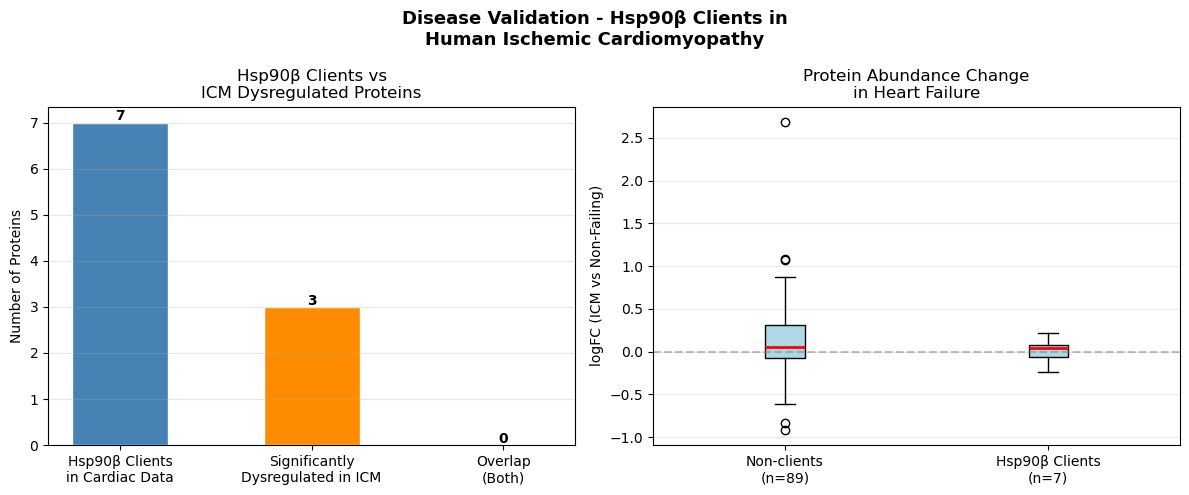

Saved as disease_validation.png


In [48]:

# FISHER'S EXACT TEST AND VISUALIZATION
from scipy.stats import fisher_exact
import matplotlib.pyplot as plt


# NUMBERS FOR FISHER'S EXACT TEST
# Total cardiac proteins = 96
# Hsp90β clients in cardiac dataset = 7
# Significantly dysregulated in ICM = 3


# How many of the 7 overlapping clients are significant?
overlap_significant = df_results[
    df_results['uniprot_id'].isin(overlap) &
    (df_results['p_value'] < 0.05)
]
print("Overlapping proteins that are significant:")
print(overlap_significant[['uniprot_id', 
                            'logFC_ICM', 
                            'p_value']].to_string())

# Build contingency table for Fisher's exact test
# Rows: Hsp90β client vs non-client
# Cols: Dysregulated in ICM vs not

total_proteins    = 96
total_clients     = 7
total_sig         = 3
clients_sig       = len(overlap_significant)
clients_not_sig   = total_clients - clients_sig
non_clients_sig   = total_sig - clients_sig
non_clients_not   = total_proteins - total_clients - non_clients_sig

contingency = [[clients_sig,     clients_not_sig],
               [non_clients_sig, non_clients_not]]

print("\nContingency Table:")
print(f"                    Dysregulated  Not Dysregulated")
print(f"Hsp90β clients  :   {clients_sig:6d}        {clients_not_sig:6d}")
print(f"Non-clients     :   {non_clients_sig:6d}        {non_clients_not:6d}")

odds_ratio, p_fisher = fisher_exact(contingency)

print(f"\nFisher's Exact Test:")
print(f"  Odds Ratio : {odds_ratio:.4f}")
print(f"  P-value    : {p_fisher:.4f}")

if p_fisher < 0.05:
    print("  SIGNIFICANT - clients over-represented in ICM")
else:
    print("  Not significant at p<0.05")


# VISUALIZATION - OVERLAP CHART


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1 - Overlap bar chart
categories = ['Hsp90β Clients\nin Cardiac Data',
              'Significantly\nDysregulated in ICM',
              'Overlap\n(Both)']
values = [total_clients, total_sig, clients_sig]
colors = ['steelblue', 'darkorange', 'green']

axes[0].bar(categories, values, color=colors, 
            edgecolor='white', width=0.5)
axes[0].set_ylabel('Number of Proteins')
axes[0].set_title('Hsp90β Clients vs\nICM Dysregulated Proteins')
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(values):
    axes[0].text(i, v + 0.05, str(v), 
                 ha='center', fontweight='bold')

# Plot 2 - LogFC comparison
# Compare logFC of clients vs non-clients in ICM
client_logfc = df_results[
    df_results['uniprot_id'].isin(overlap)
]['logFC_ICM'].values

non_client_logfc = df_results[
    ~df_results['uniprot_id'].isin(overlap)
]['logFC_ICM'].values

axes[1].boxplot([non_client_logfc, client_logfc],
                labels=['Non-clients\n(n=89)', 
                        'Hsp90β Clients\n(n=7)'],
                patch_artist=True,
                boxprops=dict(facecolor='lightblue'),
                medianprops=dict(color='red', linewidth=2))

axes[1].set_ylabel('logFC (ICM vs Non-Failing)')
axes[1].set_title('Protein Abundance Change\nin Heart Failure')
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Disease Validation - Hsp90\u03b2 Clients in\n'
             'Human Ischemic Cardiomyopathy',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('disease_validation.png',
            dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print("Saved as disease_validation.png")